# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [7]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

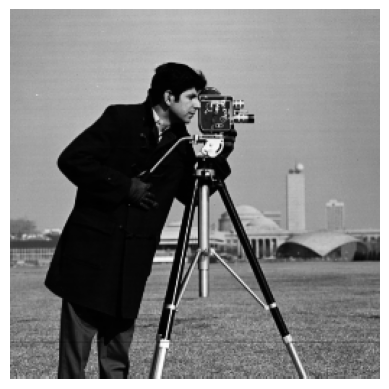

In [11]:
# ── Load image ────────────────────────────────────
img = Image.open('cameraman.png')
plt.imshow(img, cmap='gray')
plt.axis('off')  
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [12]:
# Get the size of the image
width, height = img.size
# scaling factors
cx, cy = 2, 2

In [14]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
scaled_img = img.resize((width * cx, height * cy), resample=Image.Resampling.LANCZOS)


Original size: (256, 256)
New size: (512, 512)


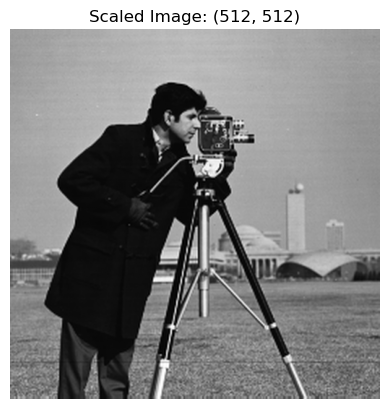

In [26]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")
print("Original size:", img.size)
print("New size:", scaled_img.size)
plt.imshow(scaled_img, cmap='gray')
plt.title(f"Scaled Image: {scaled_img.size}")
plt.axis('off')
plt.show()

 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [16]:
stretched_img = img.resize((width * 2, height * 1), resample=Image.Resampling.LANCZOS)

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Rotated size: (350, 350)


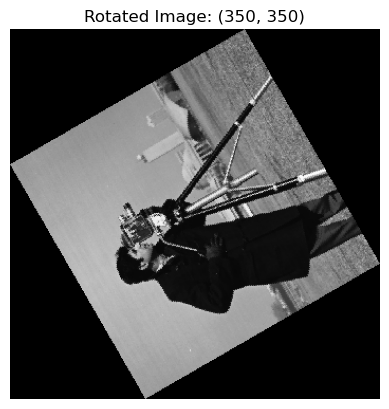

In [27]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(120, expand=True)
rotated_img.save("task1_2_rotated.jpg")
print("Rotated size:", rotated_img.size)
plt.imshow(rotated_img, cmap='gray')
plt.title(f"Rotated Image: {rotated_img.size}")
plt.axis('off')
plt.show()

### 3. Shear

In [18]:
# -- c. Get the image dimensions ────────────────────
w, h = img.size

In [19]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shx = 0.5
affine_matrix = (1, shx, 0, 0, 1, 0)

In [20]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
new_width = int(w + h * shx)
sheared_img = img.transform((new_width, h), Image.AFFINE, affine_matrix)

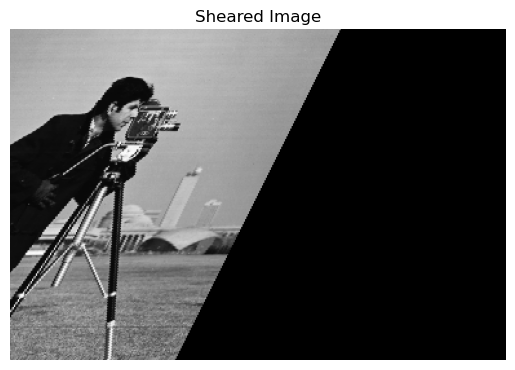

In [28]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")
plt.imshow(sheared_img, cmap='gray')
plt.title("Sheared Image")
plt.axis('off')
plt.show()

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

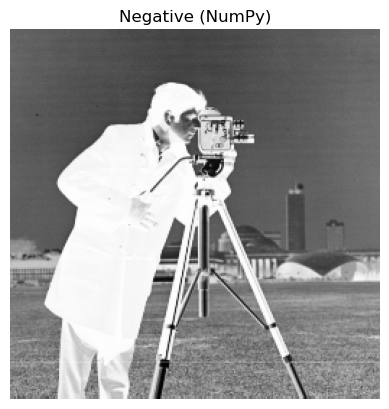

In [29]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
img_arr = np.array(img)
neg_arr = 255 - img_arr
neg_img_np = Image.fromarray(neg_arr)
plt.imshow(neg_img_np, cmap='gray')
plt.title("Negative (NumPy)")
plt.axis('off')
plt.show()

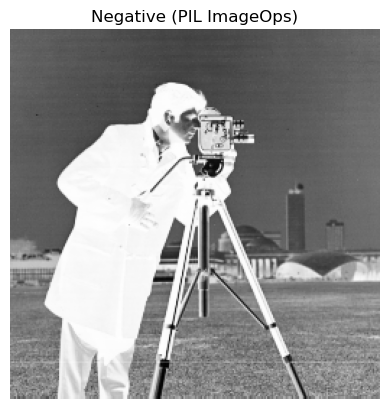

In [30]:
# Method 2: PIL's ImageOps
neg_img_pil = ImageOps.invert(img.convert("L"))
plt.imshow(neg_img_pil, cmap='gray')
plt.title("Negative (PIL ImageOps)")
plt.axis('off')
plt.show()

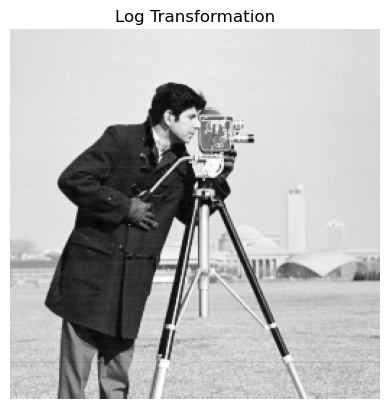

In [31]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
# Apply the log transformation to each pixel
arr = np.array(img, dtype=np.float64)
c = 255 / np.log(1 + 255)
log_transformed_arr = c * np.log(1 + arr)
log_img = Image.fromarray(np.uint8(log_transformed_arr)) 

plt.imshow(log_img, cmap='gray')
plt.title("Log Transformation")
plt.axis('off')
plt.show()

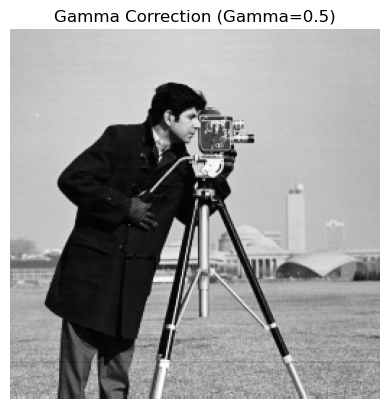

In [32]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5 
norm_arr = arr / 255.0
gamma_arr = 255 * (norm_arr ** gamma)
gamma_img = Image.fromarray(np.uint8(gamma_arr))
plt.imshow(gamma_img, cmap='gray')
plt.title(f"Gamma Correction (Gamma={gamma})")
plt.axis('off')
plt.show()